# Intención de compra: ingesta y diagnóstico
Mateo Sapia · Data Science 1 · Comisión 102390 · 29/09/2026

## Resumen
Se verificaron **12.330 sesiones y 18 variables**, sin nulos. Hay **1.908 compras (15,47 %)** y **125 filas repetidas en sus valores**. No se eliminan automáticamente porque no hay identificador de sesión. Se observa asimetría en duración y cantidad de páginas. Este checkpoint prepara los datos; no entrena un modelo ni demuestra causalidad.

## Contexto y método
Pregunta: ¿se puede clasificar la compra de una sesión por su navegación y contexto? `Revenue` es el objetivo binario. La unidad de análisis es la sesión; los agregados son de la sesión completa. El eventual modelo será retrospectivo. No se utilizará `PageValues` sin descartar fuga de información.

### Supuestos y límites
Los registros son históricos y no representan ventas actuales. Los códigos enteros de navegador/región/tráfico son categorías. Las reglas de segmentación son operativas e ilustrativas; no implican probabilidad de compra. No hay identificador ni fecha exacta para reconstruir sesiones.

## 1. Ingesta y primer vistazo
Fuente: [UCI - Online Shoppers Purchasing Intention](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset) · Sakar y Kastro (2018), DOI 10.24432/C5F88Q · CC BY 4.0.
Se usa primero el CSV original incluido; la descarga pública sirve como respaldo al abrir el notebook solo en Colab.
SHA-256 esperado: `b3055ee355f59134d851d32641183cb4a8b45def7124d2f50442a042f358e0d9`.

In [1]:
from pathlib import Path
import io
import zipfile
import hashlib
import urllib.request
import numpy as np
import pandas as pd
from IPython.display import display

data_path = Path("data/online_shoppers_intention.csv")
if not data_path.exists():
    url = "https://archive.ics.uci.edu/static/public/468/online%2Bshoppers%2Bpurchasing%2Bintention%2Bdataset.zip"
    with urllib.request.urlopen(url, timeout=60) as response:
        with zipfile.ZipFile(io.BytesIO(response.read())) as archive:
            csv_bytes = archive.read("online_shoppers_intention.csv")
    data_path.parent.mkdir(exist_ok=True)
    data_path.write_bytes(csv_bytes)

digest = hashlib.sha256(data_path.read_bytes()).hexdigest()
assert digest == "b3055ee355f59134d851d32641183cb4a8b45def7124d2f50442a042f358e0d9", "El archivo difiere del validado"
df = pd.read_csv(data_path)
print("Archivo verificado:", data_path.name)
print("Dimensiones:", df.shape)
# Vista estilizada, transpuesta solo para facilitar la lectura de 18 variables.
display(df.head(5).T.style.set_caption("Primeras cinco sesiones"))

Archivo verificado: online_shoppers_intention.csv
Dimensiones: (12330, 18)


,0,1,2,3,4
Administrative,0,0,0,0,0
Administrative_Duration,0.000000,0.000000,0.000000,0.000000,0.000000
Informational,0,0,0,0,0
Informational_Duration,0.000000,0.000000,0.000000,0.000000,0.000000
ProductRelated,1,2,1,2,10
ProductRelated_Duration,0.000000,64.000000,0.000000,2.666667,627.500000
BounceRates,0.200000,0.000000,0.200000,0.050000,0.020000
ExitRates,0.200000,0.100000,0.200000,0.140000,0.050000
PageValues,0.000000,0.000000,0.000000,0.000000,0.000000
SpecialDay,0.000000,0.000000,0.000000,0.000000,0.000000


## 2. Radiografía técnica

In [2]:
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])
df.info()
display(df.dtypes.astype(str).rename("tipo_leido").to_frame())

Filas: 12330 | Columnas: 18
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  Traff

,tipo_leido
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


Los tipos se leen sin números almacenados como texto en las variables cuantitativas. Sin embargo, `OperatingSystems`, `Browser`, `Region` y `TrafficType` son códigos nominales y sus promedios no tienen interpretación de negocio. `Month` y `VisitorType` son texto categórico; `Revenue` y `Weekend` son booleanos. En la siguiente etapa se convertirán las categorías explícitamente.

In [3]:
# describe completo, transpuesto para no perder ninguna columna numérica.
display(df.describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315,3.322,0.0,0.000,1.000,4.000,27.000
Administrative_Duration,12330.0,80.819,176.779,0.0,0.000,7.500,93.256,3398.750
Informational,12330.0,0.504,1.270,0.0,0.000,0.000,0.000,24.000
Informational_Duration,12330.0,34.472,140.749,0.0,0.000,0.000,0.000,2549.375
ProductRelated,12330.0,31.731,44.476,0.0,7.000,18.000,38.000,705.000
ProductRelated_Duration,12330.0,1194.746,1913.669,0.0,184.138,598.937,1464.157,63973.522
BounceRates,12330.0,0.022,0.048,0.0,0.000,0.003,0.017,0.200
ExitRates,12330.0,0.043,0.049,0.0,0.014,0.025,0.050,0.200
PageValues,12330.0,5.889,18.568,0.0,0.000,0.000,0.000,361.764
SpecialDay,12330.0,0.061,0.199,0.0,0.000,0.000,0.000,1.000


### Hallazgos estadísticos
1. `ProductRelated_Duration` tiene media **1.194,746 s**, mediana **598,937 s** y máximo **63.973,522 s**. La media supera ampliamente la mediana: hay una cola derecha y observaciones extremas por revisar. No se eliminan sin conocer su origen.
2. `ProductRelated` presenta mediana **18 páginas** y máximo **705** (media **31,731**). La dispersión también sugiere asimetría; conviene contrastar medianas y rangos intercuartílicos.
3. `PageValues` tiene percentil 75 igual a **0** y máximo **361,764**. Además de su concentración en cero, podría incorporar información relacionada con compras: se excluirá del conjunto de predictores.

Los ceros en páginas informativas/administrativas pueden significar que no se visitaron; no se imputan como si fueran faltantes.

## 3. Diagnóstico de datos faltantes y repetidos

In [4]:
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje_nulo": df.isna().mean().mul(100)
}).sort_values("porcentaje_nulo", ascending=False, kind="stable")
display(nulos)
print("Filas repetidas en valores:", int(df.duplicated().sum()))
print("Compras:", int(df["Revenue"].sum()))
print("Proporción de compra:", round(df["Revenue"].mean() * 100, 4), "%")
assert nulos["nulos"].sum() == 0
assert df.shape == (12330, 18)

,nulos,porcentaje_nulo
Administrative,0,0.0
Administrative_Duration,0,0.0
Informational,0,0.0
Informational_Duration,0,0.0
ProductRelated,0,0.0
ProductRelated_Duration,0,0.0
BounceRates,0,0.0
ExitRates,0,0.0
PageValues,0,0.0
SpecialDay,0,0.0


Filas repetidas en valores: 125
Compras: 1908
Proporción de compra: 15.4745 %


Todas las columnas tienen **0 % de nulos**; el ranking conserva todas las columnas aunque empaten. La ausencia de nulos no asegura ausencia de errores. Se conservan los registros repetidos porque no existe una clave para demostrar duplicidad de eventos. Antes del modelado se analizará su impacto en la partición de entrenamiento/prueba.

## 4. Funciones personalizadas: def y lambda

In [5]:
def intensidad_navegacion(paginas):
    """Segmenta páginas de producto con umbrales operativos, no predictivos."""
    if pd.isna(paginas):
        return "Sin dato"
    elif paginas < 10:
        return "Baja"
    elif paginas < 40:
        return "Media"
    else:
        return "Alta"

# Se usa copia para preservar el dataset original.
df_transformado = df.copy()
df_transformado["IntensidadNavegacion"] = (
    df_transformado["ProductRelated"].apply(intensidad_navegacion)
)
df_transformado["MinutosProducto"] = (
    df_transformado["ProductRelated_Duration"].apply(lambda segundos: segundos / 60)
)
display(df_transformado[["ProductRelated", "IntensidadNavegacion",
                        "ProductRelated_Duration", "MinutosProducto"]].head())

# Casos de frontera y comprobación dimensional.
assert [intensidad_navegacion(x) for x in [0, 9, 10, 39, 40, np.nan]] == [
    "Baja", "Baja", "Media", "Media", "Alta", "Sin dato"
]
assert np.allclose(df_transformado["MinutosProducto"] * 60,
                   df["ProductRelated_Duration"])
print("Funciones verificadas; columnas nuevas:", df_transformado.shape[1] - df.shape[1])

,ProductRelated,IntensidadNavegacion,ProductRelated_Duration,MinutosProducto
0,1,Baja,0.000000,0.000000
1,2,Baja,64.000000,1.066667
2,1,Baja,0.000000,0.000000
3,2,Baja,2.666667,0.044444
4,10,Media,627.500000,10.458333


Funciones verificadas; columnas nuevas: 2


Los umbrales separan sesiones de exploración corta, intermedia y extensa para facilitar un análisis posterior. Se declaran explícitamente y no se ajustaron para maximizar la relación con `Revenue`. La conversión a minutos no redondea los datos base ni altera su escala relativa.

## 5. Visualización del diagnóstico

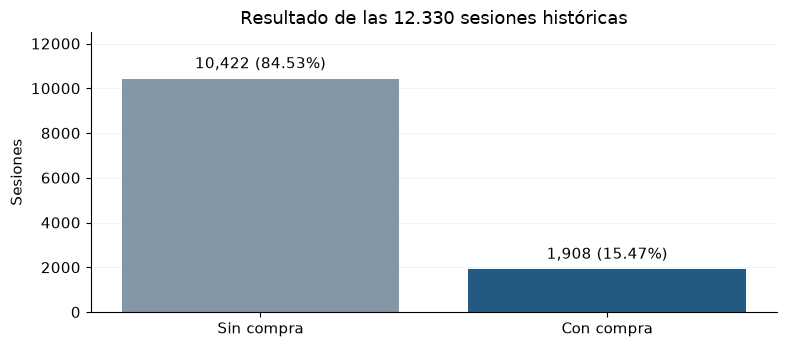

In [6]:
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (8, 3.6), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
fig, ax = plt.subplots()
cuentas = df["Revenue"].value_counts().reindex([False, True])
bars = ax.bar(["Sin compra", "Con compra"], cuentas.values,
              color=["#8497A8", "#235A81"])
ax.bar_label(bars, labels=[f"{v:,} ({v / len(df):.2%})" for v in cuentas], padding=5)
ax.set(title="Resultado de las 12.330 sesiones históricas", ylabel="Sesiones")
ax.set_ylim(0, 12500)
ax.grid(axis="y", alpha=.15)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

La clase con compra representa **15,47 %**. Un clasificador que siempre prediga no compra obtendría 84,53 % de accuracy, por lo que esa métrica aislada no es suficiente. El gráfico describe este archivo y no una tasa de conversión actual.

## Conclusiones
La ingesta y las dos funciones se ejecutaron sin errores. No se requiere imputación por nulos en el archivo actual. La asimetría, los códigos nominales y la posible fuga de `PageValues` orientan el siguiente checkpoint. El CSV original permanece intacto; las dos variables calculadas viven en una copia.

# Checkpoint 1: estructura inicial y saneamiento
## 6. Validación semántica de tipos
Se parte de `df`, el CSV original de 12.330 filas y 18 columnas cargado y perfilado arriba. Las variables calculadas de la preentrega 2 permanecen disponibles en `df_transformado`, pero no se agregan dos veces al archivo saneado.

In [7]:
df_base = df.copy()
categoricas = ["OperatingSystems", "Browser", "Region", "TrafficType",
               "Month", "VisitorType"]
for columna in categoricas:
    df_base[columna] = df_base[columna].astype("category")
cuantitativas = ["Administrative", "Administrative_Duration", "Informational",
                "Informational_Duration", "ProductRelated",
                "ProductRelated_Duration", "BounceRates", "ExitRates",
                "PageValues", "SpecialDay"]
for columna in cuantitativas:
    df_base[columna] = pd.to_numeric(df_base[columna], errors="raise")
df_base.info()
display(df_base[cuantitativas].describe().T.round(3))

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Administrative           12330 non-null  int64   
 1   Administrative_Duration  12330 non-null  float64 
 2   Informational            12330 non-null  int64   
 3   Informational_Duration   12330 non-null  float64 
 4   ProductRelated           12330 non-null  int64   
 5   ProductRelated_Duration  12330 non-null  float64 
 6   BounceRates              12330 non-null  float64 
 7   ExitRates                12330 non-null  float64 
 8   PageValues               12330 non-null  float64 
 9   SpecialDay               12330 non-null  float64 
 10  Month                    12330 non-null  category
 11  OperatingSystems         12330 non-null  category
 12  Browser                  12330 non-null  category
 13  Region                   12330 non-null  category
 14  TrafficType      

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315,3.322,0.0,0.000,1.000,4.000,27.000
Administrative_Duration,12330.0,80.819,176.779,0.0,0.000,7.500,93.256,3398.750
Informational,12330.0,0.504,1.270,0.0,0.000,0.000,0.000,24.000
Informational_Duration,12330.0,34.472,140.749,0.0,0.000,0.000,0.000,2549.375
ProductRelated,12330.0,31.731,44.476,0.0,7.000,18.000,38.000,705.000
ProductRelated_Duration,12330.0,1194.746,1913.669,0.0,184.138,598.937,1464.157,63973.522
BounceRates,12330.0,0.022,0.048,0.0,0.000,0.003,0.017,0.200
ExitRates,12330.0,0.043,0.049,0.0,0.014,0.025,0.050,0.200
PageValues,12330.0,5.889,18.568,0.0,0.000,0.000,0.000,361.764
SpecialDay,12330.0,0.061,0.199,0.0,0.000,0.000,0.000,1.000


## 7. Tres filtros booleanos con auditoría
Los filtros 1 y 2 validan rangos y no tienen por qué quitar filas. El filtro 3 delimita la población a sesiones que visitaron al menos una página de producto. No depende de la variable objetivo: se conservan compras y no compras. La interpretación posterior se limita a esta población.

In [8]:
auditoria = []
def registrar(nombre, antes, despues):
    auditoria.append({"regla": nombre, "entrada": len(antes),
                      "salida": len(despues),
                      "excluidas": len(antes) - len(despues)})

# Filtro 1: conteos y tiempos no negativos y finitos.
conteos_tiempos = cuantitativas[:6]
mask1 = (df_base[conteos_tiempos].ge(0).all(axis=1)
         & np.isfinite(df_base[conteos_tiempos]).all(axis=1))
df_f1 = df_base.loc[mask1].copy()
registrar("1. Conteos y tiempos válidos", df_base, df_f1)

# Filtro 2: proporciones dentro del dominio válido [0, 1].
tasas = ["BounceRates", "ExitRates", "SpecialDay"]
mask2 = (df_f1[tasas].ge(0) & df_f1[tasas].le(1)).all(axis=1)
df_f2 = df_f1.loc[mask2].copy()
registrar("2. Tasas entre cero y uno", df_f1, df_f2)

# Filtro 3: población elegida, visitantes de páginas de producto.
mask3 = df_f2["ProductRelated"].gt(0)
df_f3 = df_f2.loc[mask3].copy()
registrar("3. Al menos una página de producto", df_f2, df_f3)
display(pd.DataFrame(auditoria))

# Selección de columnas: evita una variable de posible fuga de información.
df_saneado = df_f3.drop(columns=["PageValues"])
print("Dimensiones finales:", df_saneado.shape)
print("Nulos finales:", int(df_saneado.isna().sum().sum()))
print("Compras en población final:", int(df_saneado["Revenue"].sum()))
assert df_saneado.shape == (12292, 17)
assert len(df) == len(df_saneado) + sum(r["excluidas"] for r in auditoria)
assert "PageValues" not in df_saneado.columns
df_saneado.to_csv("data/sesiones_saneadas.csv", index=False)
pd.DataFrame(auditoria).to_csv("data/auditoria_filtros.csv", index=False)
print("CSV saneado y auditoría guardados.")

,regla,entrada,salida,excluidas
0,1. Conteos y tiempos válidos,12330,12330,0
1,2. Tasas entre cero y uno,12330,12330,0
2,3. Al menos una página de producto,12330,12292,38


Dimensiones finales: (12292, 17)
Nulos finales: 0
Compras en población final: 1902
CSV saneado y auditoría guardados.


## 8. Reflexión final
Los dos controles de validez conservan todas las filas: no se detectaron rangos inválidos en ellos. La selección de sesiones con páginas de producto excluye **38 registros**, dejando **12.292 filas**. Se retira `PageValues`, de modo que quedan **17 columnas** (16 predictores candidatos y el objetivo). Esto es una decisión de alcance, no una afirmación de que las sesiones excluidas sean errores.

No se imputan valores porque no hay nulos. Se corrige la representación de códigos nominales y se mantienen valores extremos a la espera de investigación. Los CSV no preservan el dtype `category`: al recargarlos debe aplicarse la conversión de la sección 6. Los 125 patrones repetidos requieren revisión antes de dividir los datos para modelado; no se borraron automáticamente.

Variables clave: `ProductRelated`, `ProductRelated_Duration`, `BounceRates`, `ExitRates`, `VisitorType`, `Month`, `Weekend` y `Revenue`. La etapa siguiente contrastará distribuciones y asociaciones; todavía no se presenta un modelo ni se promete utilidad en tiempo real.

## Referencia
Sakar, C. y Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset. UCI Machine Learning Repository. DOI: https://doi.org/10.24432/C5F88Q. CC BY 4.0. Consulta 29/09/2026.